# 04 - Método da bisseção
Vamos aprender sobre como usar o método da bisseção para encontrar as raízes de funções reais.

Crie uma nova branch (versão) do repositório:

```bash
git branch semana4
```

Faça o checkout nessa nova branch:

```bash
git checkout semana4
```

A partir desta atividade, os arquivos de algoritmos ficarão dentro da pasta utils.

```txt
├─ utils/
│   └─ __init__.py
│   └─ algoritmos.py
```

<hr />

## Atividade 1
Escreva o método da bisseção dentro do arquivo $utils/algoritmos.py$.

In [1]:
def bissecao(f,     # função que queremos encontrar a raiz
              a,    # a início do intervalo
              b,    # b fim do intervalo
              TOL,   # erro tolerado
              iter=16):  # número máximo de iterações
    c = (a + b) / 2  # ponto médio entre os valores a e b
    if f(a) * f(b) > 0:
        raise ValueError("Nenhuma raiz encontrada no intervalo.")
    else:
        i = 0  # variável contador
        ERRO = abs(f(b) - f(a))  # diferença entre os valores de y

        while ERRO > TOL and i < iter:  # loop iterativo com parada
            c = (a + b) / 2.0
            if f(c) == 0:
                return c, i
            elif f(a) * f(c) < 0:
                b = c
            else:
                a = c
            i += 1
            ERRO = abs(f(b) - f(a))
        return c, i

Importe e teste a função:  

$$
f(x) = x^3 - x - 2
$$

Em que os valores iniciais a e b são obtidos graficamente.

In [4]:
%pip install numpy matplotlib


[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


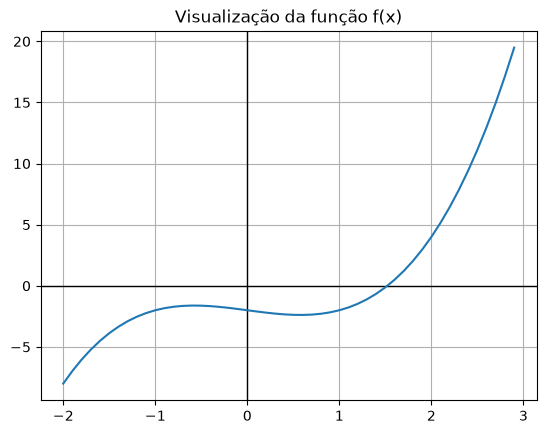

raiz = 1.5213775634765625 , i = 16


In [1]:
import numpy as np
import matplotlib.pyplot as plt

import sys
import os

# Sobe um nível para a raiz do projeto e adiciona ao caminho do sistema
sys.path.append(os.path.abspath(os.path.join('..')))

# Agora você importa suas ferramentas da pasta utils
from utils.algoritmos import bissecao

# Definição da função
def f(x):
    return x**3 - x - 2

def plot(f, number=1):
    # Intervalo para plotar
    x_vals = np.arange(-2, 3, 0.1)
    y_vals = f(x_vals)

    plt.axhline(0, color="black", linewidth=1)  # eixo x
    plt.axvline(0, color="black", linewidth=1)  # eixo y
    plt.plot(x_vals, y_vals)
    plt.grid(True)
    plt.title("Visualização da função f(x)")
    plt.show()
    plt.close()

def main():
    plot(f, 1)
    r, i = bissecao(f, 1, 2, 1e-15)
    print(f"raiz = {r} , i = {i}")

if __name__ == "__main__":
    main()

## Atividade 2
Considere a equação  

$$
\sqrt{x} = \cos(x).
$$  

Use o método da bisseção com intervalo inicial obtido por gráfico (entre 0 e 1) para calcular um valor aproximado com precisão de $10^{-4}$ para no máximo 4 iterações.

**Resposta:**  
$
x \approx 0.6875
$ 

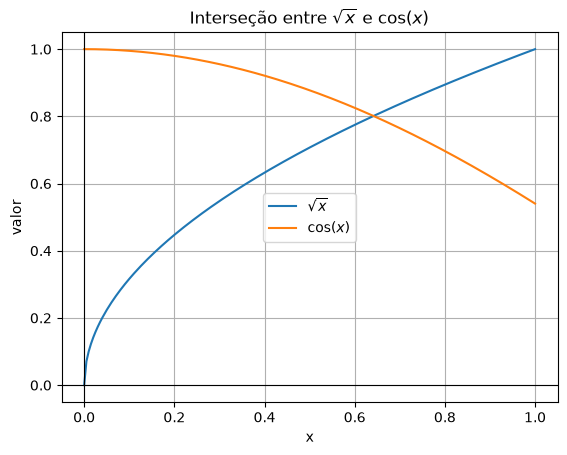

raiz aproximada = 0.6875
iterações = 4


In [3]:
import numpy as np
import matplotlib.pyplot as plt


def f2(x):
    return np.sqrt(x) - np.cos(x)


x_vals = np.linspace(0, 1, 200)
plt.plot(x_vals, np.sqrt(x_vals), label=r"$\sqrt{x}$")
plt.plot(x_vals, np.cos(x_vals), label=r"$\cos(x)$")
plt.axvline(0, color="black", linewidth=0.8)
plt.axhline(0, color="black", linewidth=0.8)
plt.grid(True)
plt.xlabel("x")
plt.ylabel("valor")
plt.title(r"Interseção entre $\sqrt{x}$ e $\cos(x)$")
plt.legend()
plt.show()
plt.close()

raiz, iteracoes = bissecao(f2, 0, 1, 1e-4, iter=4)
print(f"raiz aproximada = {raiz:.4f}")
print(f"iterações = {iteracoes}")

## Atividade 3
Trace o gráfico e isole as três primeiras raízes positivas da função:  

$$
f(x) = 5\sin(x^2) - \exp\!\left(\frac{x}{10}\right)
$$  

em intervalos de comprimento $(0.1)$. Então, use o método da bisseção para obter aproximações dos zeros com precisão de $10^{-5}$.  

**Resposta:**  

- Intervalo $(0.4, 0.5)$, zero em $(x \approx 0.45931)$.  
- Intervalo $(1.7, 1.8)$, zero em $(x \approx 1.7036)$.  
- Intervalo $(2.5, 2.6)$, zero em $(x \approx 2.5582)$. 

Intervalo (0.4, 0.5)
Raiz = 0.45931

Intervalo (1.7, 1.8)
Raiz = 1.70357

Intervalo (2.5, 2.6)
Raiz = 2.55821



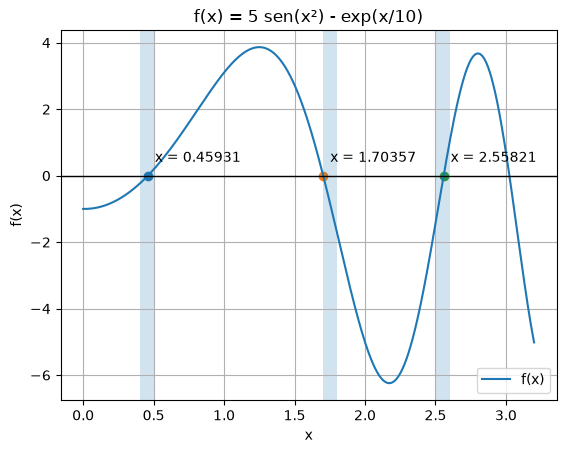

In [8]:
import math
import matplotlib.pyplot as plt

def f(x):
    return 5 * math.sin(x**2) - math.exp(x / 10)

def bissecao(a, b, tol=1e-5):
    while (b - a) / 2 > tol:
        m = (a + b) / 2

        if f(a) * f(m) < 0:
            b = m
        else:
            a = m

    return (a + b) / 2

intervalos = [(0.4, 0.5), (1.7, 1.8), (2.5, 2.6)]

raizes = []

for a, b in intervalos:
    raiz = bissecao(a, b)
    raizes.append(raiz)
    print(f"Intervalo ({a:.1f}, {b:.1f})")
    print(f"Raiz = {raiz:.5f}")
    print()

x = [i / 1000 for i in range(0, 3201)]
y = [f(valor) for valor in x]

plt.plot(x, y, label="f(x)")
plt.axhline(0, color="black", linewidth=1)

for raiz in raizes:
    plt.scatter(raiz, f(raiz))
    plt.annotate(
        f"x = {raiz:.5f}",
        (raiz, f(raiz)),
        xytext=(5, 10),
        textcoords="offset points"
    )

for a, b in intervalos:
    plt.axvspan(a, b, alpha=0.2)

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("f(x) = 5 sen(x²) - exp(x/10)")
plt.grid(True)
plt.legend()
plt.show()

## Atividade 4
O desenho abaixo mostra um circuito não linear envolvendo uma fonte de tensão constante, um diodo retificador e um resistor.  

Sabendo que a relação entre a corrente ($I_d$) e a tensão ($v_d$) no diodo é dada pela seguinte expressão:

$ I_d = I_R \left( \exp\left(\tfrac{v_d}{v_t}\right) - 1 \right) $

onde $I_R$ é a corrente de condução reversa e $v_t$ a tensão térmica, dada por  

$ v_t = \tfrac{kT}{q} $

com $k$ a constante de Boltzmann, $T$ a temperatura de operação e $q$ a carga do elétron.  

Aqui, $I_R = 1\,pA = 10^{-12}\,A$, $T = 300\,K$.  

Escreva o problema como uma equação na incógnita $v_d$, usando o método da bisseção, e resolva-o com **3 algarismos significativos** para os seguintes casos:

- $V = 30 \, V$ e $R = 1 \, k\Omega$  
- $V = 3 \, V$ e $R = 1 \, k\Omega$  
- $V = 3 \, V$ e $R = 10 \, k\Omega$  
- $V = 300 \, mV$ e $R = 1 \, k\Omega$  
- $V = -300 \, mV$ e $R = 1 \, k\Omega$  
- $V = -30 \, V$ e $R = 1 \, k\Omega$  
- $V = -30 \, V$ e $R = 10 \, k\Omega$  

![Circuito](https://www.ufrgs.br/reamat/CalculoNumerico/livro-py/main4x.png)

**Dica:**  
A equação do circuito é:

$ V = R I_d + v_d $

**Resposta:**  
a) $0.623$  
b) $0.559$  
c) $0.500$  
d) $0.300$  
e) $-0.300$  
f) $-30$  
g) $-30$

In [9]:
import math

k = 1.380649e-23
q = 1.602176634e-19
T = 300
IR = 1e-12

vt = k * T / q

def f(vd, V, R):
    return R * IR * (math.exp(vd / vt) - 1) + vd - V

def bissecao(V, R, a, b, tol=1e-12):
    while (b - a) / 2 > tol:
        x = (a + b) / 2

        if f(a, V, R) * f(x, V, R) < 0:
            b = x
        else:
            a = x

    return (a + b) / 2

casos = [
    (30, 1000, 0, 30),
    (3, 1000, 0, 3),
    (3, 10000, 0, 3),
    (0.3, 1000, 0, 0.3),
    (-0.3, 1000, -0.3, 0),
    (-30, 1000, -30, 0),
    (-30, 10000, -30, 0)
]

for i, (V, R, a, b) in enumerate(casos, 1):
    vd = bissecao(V, R, a, b)
    print(f"{chr(96+i)}) V = {V:g} V, R = {R:g} Ω -> vd = {vd:.3g} V")

a) V = 30 V, R = 1000 Ω -> vd = 0.623 V
b) V = 3 V, R = 1000 Ω -> vd = 0.559 V
c) V = 3 V, R = 10000 Ω -> vd = 0.5 V
d) V = 0.3 V, R = 1000 Ω -> vd = 0.3 V
e) V = -0.3 V, R = 1000 Ω -> vd = -0.3 V
f) V = -30 V, R = 1000 Ω -> vd = -30 V
g) V = -30 V, R = 10000 Ω -> vd = -30 V


## Atividade 5
Calcule o comprimento do cabo ($C$) entre duas torres de transmissão (i.e., a catenária).  

A distância entre as torres é de $d = 500 \, m$.  

A flecha máxima permitida é $f_{max} = 50 \, m$.  

Flecha é a distância vertical entre uma reta que liga os dois pontos de fixação.  

A flecha ($f$) depende do comprimento do vão ($d$) e da tração ($C$) aplicada ao cabo.  

O seu modelo matemático pode ser:

$ f = C \left[ \cosh\left(\tfrac{d}{2C}\right) - 1 \right] \quad $

**Resposta:** $633.1621 \, m$

In [10]:
import math

d = 500
fmax = 50

def f(C):
    return C * (math.cosh(d / (2 * C)) - 1) - fmax

def bissecao(a, b, tol=1e-10):
    while (b - a) / 2 > tol:
        C = (a + b) / 2

        if f(a) * f(C) < 0:
            b = C
        else:
            a = C

    return (a + b) / 2

C = bissecao(600, 700)

print(f"C = {C:.4f} m")

C = 633.1622 m


## Atividade 6
Um retificador de meia onda a diodo alimenta uma carga indutiva-resistiva ($f = 1 \, kHz$, $L = 100 \, mH$ e $R = 1 \, k\Omega$).  

Encontre o ângulo $\beta$ para o qual a corrente $I_d$ no diodo se anula.  

Considere o seguinte modelo matemático:

$ I_d = \sin(\beta - \phi) + \sin(\phi)e^{-\tfrac{\beta}{\tan(\phi)}} \quad $

com  

$ \tan(\phi) = \tfrac{2\pi f L}{R} $

**Resposta:** $\beta = 212.2284^\circ$

In [11]:
import math

f = 1000
L = 0.1
R = 1000

tan_phi = 2 * math.pi * f * L / R
phi = math.atan(tan_phi)

def I(beta):
    return math.sin(beta - phi) + math.sin(phi) * math.exp(-beta / tan_phi)

def bissecao(a, b, tol=1e-10):
    while (b - a) / 2 > tol:
        x = (a + b) / 2

        if I(a) * I(x) < 0:
            b = x
        else:
            a = x

    return (a + b) / 2

beta = bissecao(3, 4)

print(f"tan(phi) = {tan_phi:.6f}")
print(f"phi = {math.degrees(phi):.4f} graus")
print(f"beta = {math.degrees(beta):.4f} graus")

tan(phi) = 0.628319
phi = 32.1419 graus
beta = 212.2258 graus


## Versionando o código

Submeta a branch para o servidor:

```bash
git add .
git commit -m "Semana 4"
git push origin semana4
```